## Necessary Imports


In [1]:
import os
import cv2
import torch
import numpy as np 
import matplotlib.pyplot as plt
from PIL import Image
from torch import nn, optim
from torchvision import transforms, datasets
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torch.utils.data import DataLoader

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

## Device Configuration

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:',device)

Device: cuda


## Dataset Path


In [3]:
train_path = r"D:\Seed Quality Prediction\data-20260503T170400Z-3-001\data\train"
val_path = r"D:\Seed Quality Prediction\data-20260503T170400Z-3-001\data\val"

## Image Transformation

In [4]:
train_transform = transforms.Compose([
    # transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(
        224, scale = (0.9, 1.0)
    ),
    transforms.ColorJitter(
        brightness=0.2,
        saturation=0.2,
        contrast = 0.2
    ),

    # transforms.TrivialAugmentWide(),  
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225] 
    ),
    transforms.RandomErasing(p=0.15) 
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## Load DataSet


In [5]:
train_set = datasets.ImageFolder(
    train_path,
    transform = train_transform
)

test_set = datasets.ImageFolder(
    val_path,
    transform = test_transform
)

## Data Loader


In [6]:
train_loader = DataLoader(
    train_set,
    batch_size=32,
    shuffle = True,
    num_workers=4,
    pin_memory = True
)
test_loader = DataLoader(
    test_set,
    batch_size = 32,
    shuffle = False,
    num_workers = 4,
    pin_memory = True
)

In [7]:
classes = test_set.classes
print("Classes:",classes)

Classes: ['broken', 'discolored', 'pure', 'silkcut']


## EfficientNet

In [8]:
weights = EfficientNet_B0_Weights.DEFAULT
base_model = efficientnet_b0(weights = weights)

for param in base_model.features[:4].parameters():
    base_model.requires_grad = False

num_features = base_model.classifier[1].in_features

base_model.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(num_features,256),
    nn.ReLU(),
    nn.BatchNorm1d(256),
    nn.Dropout(0.3),
    nn.Linear(256, len(classes))
)
model = base_model.to(device)

## Loss and Optimizer

In [9]:
epochs = 10
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(
    model.parameters(),
    lr = 1e-4,
    weight_decay = 1e-4
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=epochs,
    eta_min=1e-6
)


# Training

In [10]:
# scaler = torch.cuda.amp.GradScaler()

train_acc_history = []
val_acc_history = []
loss_history = []
best_accuracy = 0.0

for epoch in range(epochs):

    # Training

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images , labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)
        
        loss.backward()

        optimizer.step()
        
        running_loss+=loss.item()
        _, predicted = torch.max(outputs,1)
        total+=labels.size(0)
        correct+=(predicted == labels).sum().item()

    train_acc = correct/total
    train_acc_history.append(train_acc)


    # Validation
    
    model.eval()

    total = 0
    correct = 0

    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total+= labels.size(0)
            correct+=(predicted == labels).sum().item()

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())
    
    val_acc = correct/total
    val_acc_history.append(val_acc)

    scheduler.step()
    
    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}\n")

print(f"Accuracy: {accuracy_score(y_true,y_pred):.2f}")

Epoch [1/10]
Training Accuracy: 0.5589
Validation Accuracy: 0.6893

Epoch [2/10]
Training Accuracy: 0.6804
Validation Accuracy: 0.7327

Epoch [3/10]
Training Accuracy: 0.7156
Validation Accuracy: 0.7643

Epoch [4/10]
Training Accuracy: 0.7387
Validation Accuracy: 0.7723

Epoch [5/10]
Training Accuracy: 0.7573
Validation Accuracy: 0.7804

Epoch [6/10]
Training Accuracy: 0.7759
Validation Accuracy: 0.7821

Epoch [7/10]
Training Accuracy: 0.7843
Validation Accuracy: 0.7827

Epoch [8/10]
Training Accuracy: 0.7975
Validation Accuracy: 0.7882

Epoch [9/10]
Training Accuracy: 0.7992
Validation Accuracy: 0.7882

Epoch [10/10]
Training Accuracy: 0.8084
Validation Accuracy: 0.7890

Accuracy: 0.79


## Confusion Matrix


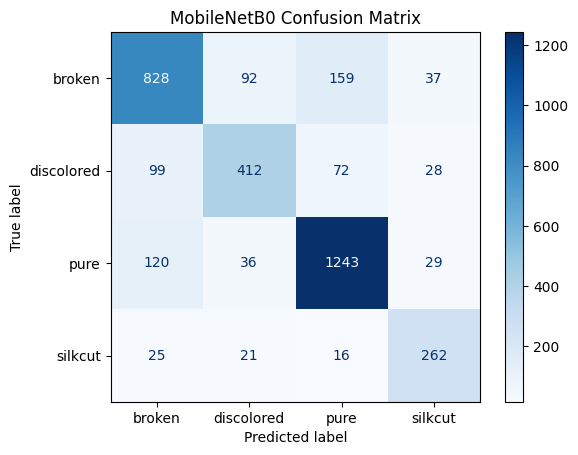

In [11]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels = classes
)

disp.plot(cmap='Blues')
plt.title("MobileNetB0 Confusion Matrix")

plt.show()

## Accuracy Graph

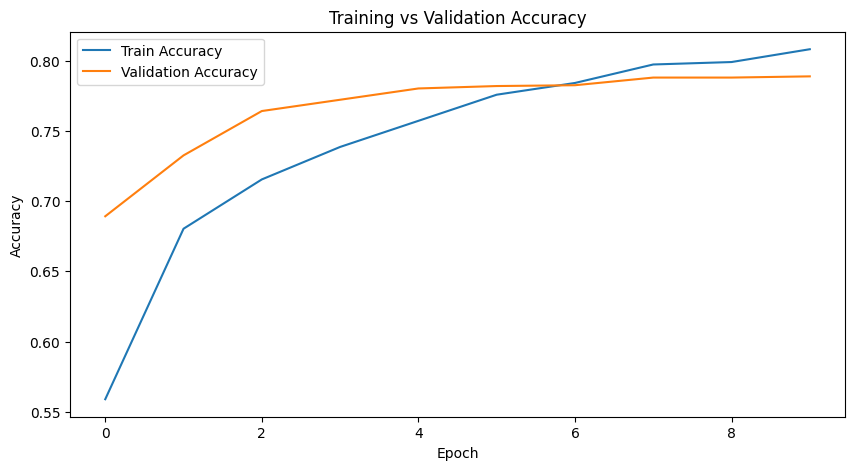

In [12]:
plt.figure(figsize=(10,5))

plt.plot(train_acc_history, label="Train Accuracy")

plt.plot(val_acc_history, label="Validation Accuracy")
plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.show()

## Class Prediction

In [13]:
# Class names
classes = train_set.classes

# Load image
image_path = r"D:\Seed Quality Prediction\data-20260503T170400Z-3-001\data\val\discolored\new_dc317_broken_002_top_223.png"

image = Image.open(image_path).convert("RGB")

# Apply validation transform
image = test_transform(image)

# Add batch dimension
image = image.unsqueeze(0)

# Move to device
image = image.to(device)

# Evaluation mode
model.eval()

with torch.no_grad():

    outputs = model(image)

    _, predicted = torch.max(outputs, 1)

    predicted_class = classes[predicted.item()]

print("Predicted Class:", predicted_class)

Predicted Class: discolored
